---
date: "2026-04-17"
date-modified: last-modified
format:
  html:
    toc: true
---


# The Newton-Pepys Problem

## 1\. Historical Context and Problem Statement

In 1693, Samuel Pepys consulted Isaac Newton regarding a wager. Pepys wanted to know which of the following three events has the highest probability of occurring, assuming all dice are perfectly fair:

  * **Event A:** Rolling at least one $6$ when rolling $6$ dice.
  * **Event B:** Rolling at least two $6$s when rolling $12$ dice.
  * **Event C:** Rolling at least three $6$s when rolling $18$ dice.

At first glance, human intuition suggests the probabilities should be identical. In all three scenarios, the ratio of the required number of $6$s to the total number of dice rolled is exactly $\frac{1}{6}$. However, Newton correctly proved this intuition wrong.

-----

## 2\. Approach 1: Naive Counting (The Complement Method)

Using the [naive definition of probability](probability-naive-definition.ipynb), the total number of possible outcomes for $n$ dice is $6^n$ (a classic application of [sampling with replacement](sampling-with-replacement.ipynb)).

Instead of calculating the massive sums for "at least $k$" sixes directly, we calculate the probability of the **complement event** (failing to meet the condition) and subtract it from 1.

  * **Event A (Complement is rolling exactly zero 6s):** There are $5^6$ ways to roll only numbers 1 through 5.
    $$P(A) = 1 - \frac{5^6}{6^6} \approx 0.6651$$

  * **Event B (Complement is rolling zero or exactly one 6):** There are $5^{12}$ ways to roll zero 6s. To roll exactly one 6, we choose 1 die to be the 6 ($\binom{12}{1}$) and the other 11 dice can be anything from 1 to 5 ($5^{11}$).
    $$P(B) = 1 - \frac{5^{12} + \binom{12}{1} 5^{11}}{6^{12}} \approx 0.6187$$

  * **Event C (Complement is rolling zero, one, or exactly two 6s):** Following the exact same combinatoric logic for zero, one, and two 6s:
    $$P(C) = 1 - \frac{5^{18} + \binom{18}{1} 5^{17} + \binom{18}{2} 5^{16}}{6^{18}} \approx 0.5973$$

-----

## 3\. Approach 2: The Binomial Distribution

Because each die roll is completely isolated, these are [independent events](independence-of-events.ipynb). Therefore, the total count of $6$s rolled follows a **Binomial Distribution**:
$$X \sim \text{Bin}(n, p)$$

Where $n$ is the number of dice, and the probability of success on a single trial is $p = \frac{1}{6}$. The probability mass function for getting exactly $k$ successes is:
$$P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}$$

We can calculate the probabilities by summing the failures and subtracting from 1:

  * **Event A ($n=6, k \ge 1$):**
    $$P(X_A \ge 1) = 1 - P(X_A = 0) = 1 - \binom{6}{0}\left(\frac{1}{6}\right)^0\left(\frac{5}{6}\right)^6 \approx 0.6651$$

  * **Event B ($n=12, k \ge 2$):**
    $$P(X_B \ge 2) = 1 - \left[ P(X_B = 0) + P(X_B = 1) \right] \approx 0.6187$$

  * **Event C ($n=18, k \ge 3$):**
    $$P(X_C \ge 3) = 1 - \left[ P(X_C = 0) + P(X_C = 1) + P(X_C = 2) \right] \approx 0.5973$$

Both mathematical proofs confirm that **Event A is the most likely outcome.**

-----

## 4\. Intuition: Why Does the Probability Drop?

Why does the probability steadily decrease as we scale the game up proportionally?

This is a direct consequence of variance, the **Law of Large Numbers**, and the **Central Limit Theorem**.

In $6n$ rolls, the *expected value* (average) number of 6s is exactly $n$. As you roll more and more dice, the actual proportion of 6s you roll will tighten closer and closer to exactly $1/6$.

  * When you roll **6 dice**, the variance is relatively high compared to the total number of dice. You only need one "lucky" die to win. The spread of possibilities is wide enough that it is relatively easy to hit or overshoot your expected value.
  * When you roll **600 dice**, the variance relative to the total shrinks massively. To win, you need at least 100 sixes. Because the Law of Large Numbers dictates that the results will cling tightly to the average, extreme over-performance becomes rare.
  * Furthermore, by the **Central Limit Theorem**, as $n$ grows, the shape of the binomial distribution smooths out into a perfectly symmetric bell curve (Normal distribution) centered precisely at the expected value ($n$). Since a perfectly symmetric, continuous bell curve has exactly $1/2$ of its area to the right of the center, the probability of hitting or exceeding the mean steadily drops toward that mathematical limit.

Therefore, as $n \to \infty$, the probability of rolling *at least* $n$ sixes in $6n$ rolls slowly drops from $\approx 2/3$ and asymptotes toward $1/2$.

-----

## 5\. Python Simulation: Probability vs. Number of Dice

The following Python script calculates and plots the exact mathematical probability of rolling at least $n$ sixes in $6n$ dice rolls, demonstrating the asymptotic drop toward $1/2$.

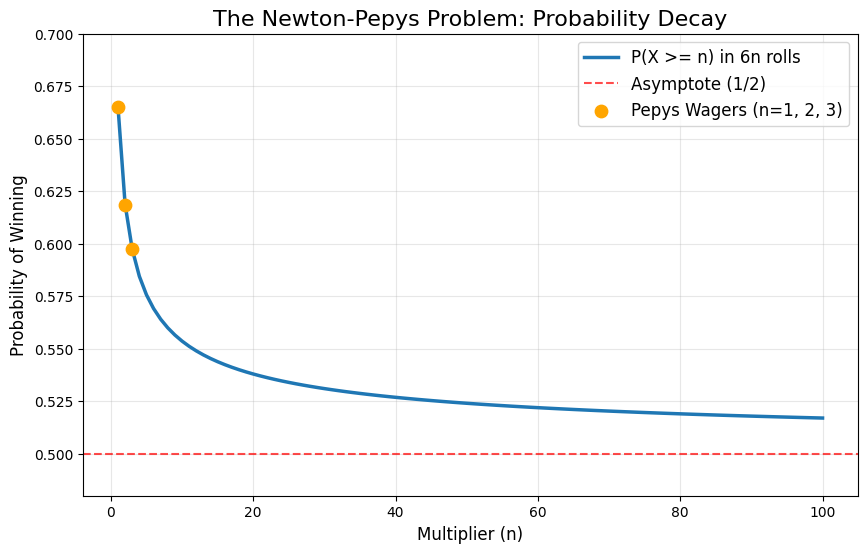

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

def prob_at_least_n_sixes(n):
    """
    Calculates the probability of getting >= n sixes in 6n rolls.
    """
    total_dice = 6 * n
    # sf(n-1) calculates P(X > n-1), which is P(X >= n)
    return binom.sf(n - 1, total_dice, 1/6)

# Generate data for n = 1 to 100 (which corresponds to 6 to 600 dice)
n_values = np.arange(1, 101)
probabilities = [prob_at_least_n_sixes(n) for n in n_values]

# Create the visualization
plt.figure(figsize=(10, 6))
plt.plot(n_values, probabilities, color='#1f77b4', linewidth=2.5, label='P(X >= n) in 6n rolls')

# Plot the asymptote at 1/2
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='Asymptote (1/2)')

# Highlight the specific Pepys wagers (n=1, 2, 3)
pepys_n = [1, 2, 3]
pepys_p = [prob_at_least_n_sixes(x) for x in pepys_n]
plt.scatter(pepys_n, pepys_p, color='orange', s=80, zorder=5, label='Pepys Wagers (n=1, 2, 3)')

# Formatting
plt.title('The Newton-Pepys Problem: Probability Decay', fontsize=16)
plt.xlabel('Multiplier (n)', fontsize=12)
plt.ylabel('Probability of Winning', fontsize=12)
plt.ylim(0.48, 0.70)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)

plt.show()